In [1]:
# import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import numpy as np
import math
import pandas as pd
# import bisect
# import uuid
from enum import Enum
# import requests
from pathlib import Path
import os
import h3

import plotly.express as px
import pandas as pd

from shapely.geometry import Polygon

from fame import *

# import random


In [2]:
R_earth_km = 6371


In [3]:
# Gemini-generated

# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [4]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [5]:
# planet_satellites = []
# 14-19 decayed

instrument_types = ["RGB", "Hyperspectral", "SAR"]

# tle_file_name_txt = "all_tles_20260121.txt"

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=["RGB"]),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=["RGB"]),
]
pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=["RGB"]),

]
tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=["Hyperspectral"]),

]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=["SAR"]),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]

loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=["RGB"])]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=["RGB"])]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=["RGB"]),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=["RGB"]),   
]

In [6]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [7]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [8]:

ground_stations = [
    Location(
        3.8,
        52,
        0,
        "Rotterdam-ish",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

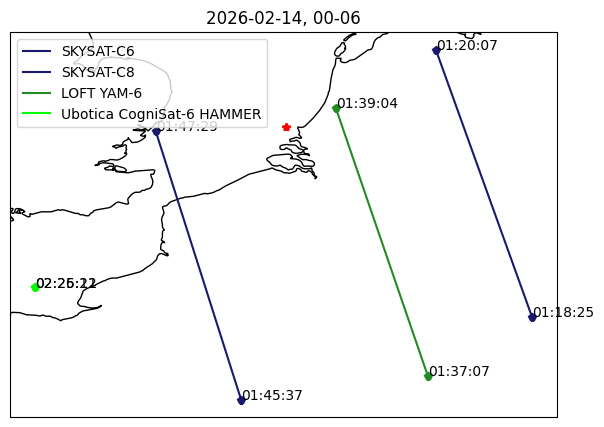

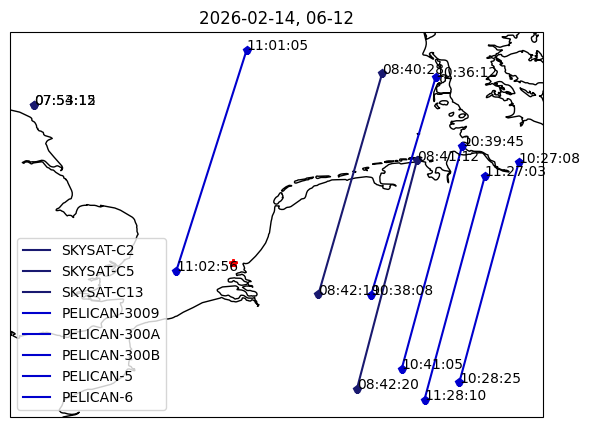

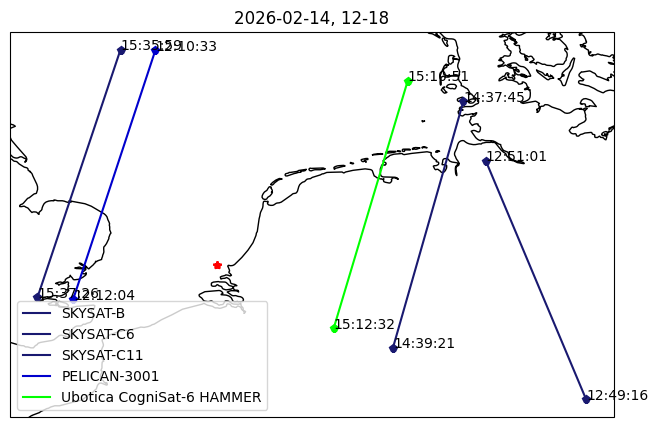

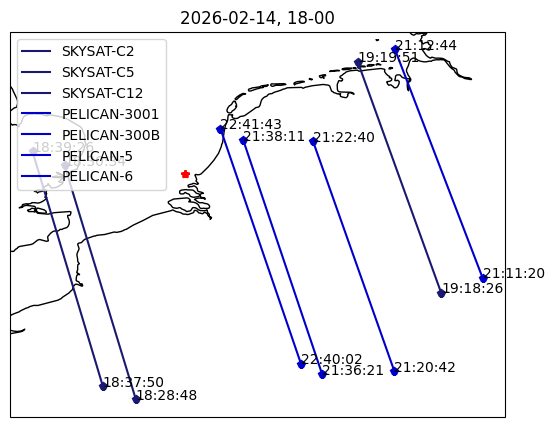

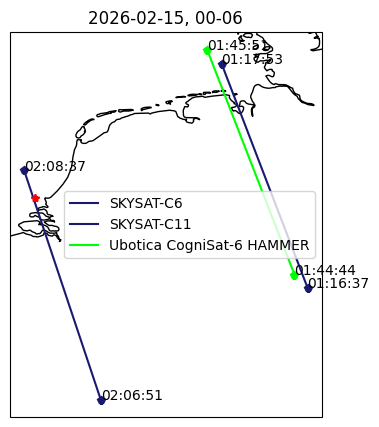

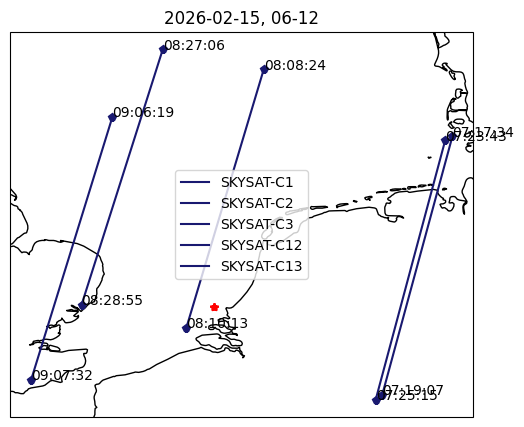

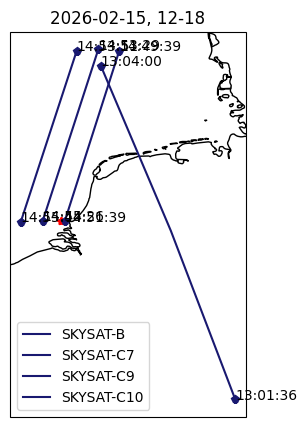

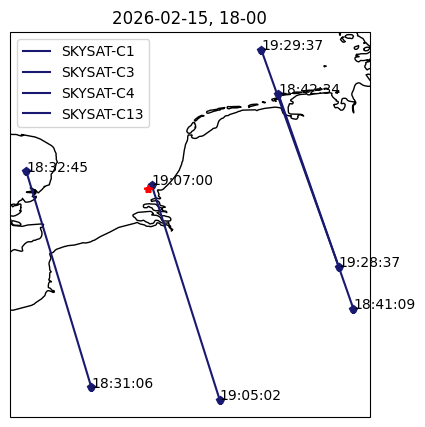

In [9]:
duration_h = 6

for start_day in range(14,16):
    for start_hour in range(0,24,duration_h):
        min_time = dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0)
        duration = dt.timedelta(seconds=3600*duration_h)
        comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
            ground_stations=ground_stations,
            satellites=all_satellites,
            min_time=min_time,
            max_time=min_time+duration,
            passes_error_s=60,
            passes_horizon_deg=45
        )

        stride_s = 60
        plot_range_s = 10800

        # comm_opportunities_by_sat

        figglobal = plt.figure(figsize=(10,5))
        axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
        # axglobal.set_global()
        axglobal.coastlines()

        # fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

        ground_station_dict = {gs.name: gs for gs in ground_stations}

        for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
            for (ground_station, satpass) in sat_passes_with_gs:
                # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
                # ax.coastlines()
            
                # request location
                # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
                # ground_station = ground_station_dict[gs]
                axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            
                # Where is the satellite?
            
                _dt = dt.timedelta(seconds=stride_s)
                time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]
            
                _orbit = satellite.orbit
                _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
                # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
                axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])
                
                axglobal.plot(_llas[0][0],_llas[0][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
                axglobal.plot(_llas[-1][0],_llas[-1][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

                axglobal.text(_llas[0][0],_llas[0][1], "{}".format(satpass.rise.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())
                axglobal.text(_llas[-1][0],_llas[-1][1], "{}".format(satpass.fall.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())

                # Where is the satellite looking?
                # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
                # axglobal.plot(
                #     [float(orequest.lon_deg), _highest_lla[0]],
                #     [float(orequest.lat_deg), _highest_lla[1]],
                #     ':k',
                #     transform=ccrs.Geodetic()
                # )
                
                # ax.plot(
                #     [float(orequest.lon_deg), _highest_lla[0]],
                #     [float(orequest.lat_deg), _highest_lla[1]],
                #     ':k',
                #     transform=ccrs.Geodetic()
                # )
                
                # request_counter += 1
        axglobal.legend()
        axglobal.set_title("{}-{}".format(min_time.strftime("%Y-%m-%d, %H"), (min_time+duration).strftime("%H")))
        plt.savefig("{}-{}-{}h.png".format(min_time.strftime("%Y-%m-%d %H"),(min_time+duration).strftime("%H"), duration_h), bbox_inches='tight')

In [10]:
PLOT_TIMELAPSE = False

# duration_h = 6

# for start_day in range(14,16):
#     for start_hour in range(0,24,duration_h):

start_time = dt.datetime(2026, 2, 14, 0, 0, 0, 0)
end_time = dt.datetime(2026, 2, 16, 0, 0, 0, 0)

if PLOT_TIMELAPSE:

        _plot_offset_deg = 8




        start_cut_time = start_time #dt.datetime(2026, 2, 15, 20, 1, 0, 0)

        tl_duration = end_time-start_time
        tl_timestep_s = 20

        streak_duration = dt.timedelta(seconds=180)
        streak_stride_s = 2

        # comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
        #     ground_stations=ground_stations,
        #     satellites=all_satellites,
        #     min_time=min_time,
        #     max_time=min_time+duration,
        #     passes_error_s=60,
        #     passes_horizon_deg=45
        # )


        # plot_range_s = 120

        # comm_opportunities_by_sat
        for frame_index in range(int(np.ceil(tl_duration.total_seconds()/tl_timestep_s))):

                time_offset = dt.timedelta(seconds=tl_timestep_s*frame_index)

                curr_time = start_time + time_offset

                if curr_time<start_cut_time:
                        continue

                figglobal = plt.figure(figsize=(10,5))
                axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
                # axglobal.set_global()
                axglobal.coastlines()

                # fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

                ground_station_dict = {gs.name: gs for gs in ground_stations}

                # for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
                #     for (ground_station, satpass) in sat_passes_with_gs:
                for satellite in all_satellites:
                        # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
                        # ax.coastlines()

                        # request location
                        # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
                        # ground_station = ground_station_dict[gs]

                        axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )

                        axes_extents = (float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg)


                        # Where is the satellite?

                        _dt = dt.timedelta(seconds=streak_stride_s)
                        # time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

                        time_steps_for_plotting = [curr_time-streak_duration + _dt*i for i in range(int(math.ceil(streak_duration.total_seconds()/_dt.total_seconds())))]

                        _orbit = satellite.orbit
                        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]

                        current_sat_lla = _llas[-1]
                        # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
                        for lla_ix in range(len(time_steps_for_plotting)-1):
                                # axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])
                                axglobal.plot([_llas[lla_ix+1][0], _llas[lla_ix][0]], [_llas[lla_ix+1][1], _llas[lla_ix][1]], transform=ccrs.Geodetic(), color=satcolor[satellite.name], alpha = (lla_ix+1)/len(_llas))

                        # axglobal.plot(_llas[0][0],_llas[0][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
                        axglobal.plot(current_sat_lla[0],current_sat_lla[1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

                        if (current_sat_lla[0]>axes_extents[0] and current_sat_lla[0]<axes_extents[1] and current_sat_lla[1]>axes_extents[2] and current_sat_lla[1]<axes_extents[3]):
                                axglobal.text(_llas[-1][0],_llas[-1][1], "{}".format(satellite.name), transform=ccrs.Geodetic(), clip_on=True)


                        # axglobal.text(_llas[0][0],_llas[0][1], "{}".format(satpass.rise.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())

                        # axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg))


                        # Where is the satellite looking?
                        # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
                        # axglobal.plot(
                        #     [float(orequest.lon_deg), _highest_lla[0]],
                        #     [float(orequest.lat_deg), _highest_lla[1]],
                        #     ':k',
                        #     transform=ccrs.Geodetic()
                        # )

                        # ax.plot(
                        #     [float(orequest.lon_deg), _highest_lla[0]],
                        #     [float(orequest.lat_deg), _highest_lla[1]],
                        #     ':k',
                        #     transform=ccrs.Geodetic()
                        # )

                        # request_counter += 1
                # axglobal.legend()
                axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())
                axglobal.set_title("{}".format(curr_time.strftime("%Y-%m-%d, %H:%M:%S")))
                plt.savefig("timelapse/Rotterdam_tl_FRAME{:05d}.png".format(frame_index), bbox_inches='tight')

In [11]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

phenomenon_update_frequency = dt.timedelta(seconds=1800)

phenomena = [
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=start_time,
        end_time=start_time+phenomenon_update_frequency,
        name = Rotterdam.name+ " {}-{}".format(start_time.strftime("%Y-%m-%d, %H"),(start_time+phenomenon_update_frequency).strftime("%H"))
    ),
]

# avg_speed_kph = 37 # 20 kts
# max_iters_per_point = 100

while phenomena[-1].end_time<end_time:
    # next_point_is_on_land = True
    # _it_guesses = 0
    # while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
    #     _it_guesses+=1
        
    #     new_heading_rad = random.random()*2*math.pi # 0 at North
    #     new_speed_kph = avg_speed_kph + random.normalvariate()
    #     dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
    #     dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

    #     dlat_rad = dy/R_earth_km
    #     dlon_rad = dx/(R_earth_km*np.cos(phenomena[-1].lat_deg*math.pi/180.))

    #     new_lat_deg = phenomena[-1].lat_deg + dlat_rad*180./math.pi
    #     new_lon_deg = phenomena[-1].lon_deg + dlon_rad*180./math.pi

    #     next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    previous_end_time = phenomena[-1].end_time
    

    phenomena.append(
        Phenomenon(
            lon_deg = Rotterdam.lon_deg,
            lat_deg = Rotterdam.lat_deg,
            alt_km=Rotterdam.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            name = Rotterdam.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

In [12]:



obs_requests_broker = [
    ObservationRequest(p.lon_deg, p.lat_deg, min_time=p.start_time, max_time=p.end_time, alt_km=p.alt_km, request_name=Rotterdam.name, min_elevation_deg=45, instrument=instrument)
    for p in phenomena for instrument in ["RGB", "Hyperspectral", "SAR"]
]

In [13]:
opportunities = find_observation_opportunities(obs_requests_broker, all_satellites)

In [14]:
opportunities_list = [
    {
        'Satellite': s.name,
        'start_time': o.rise.time,
        'highest_time': o.highest.time,
        'end_time': o.fall.time,
        'instrument': r.instrument,
    }
    for r in opportunities.keys()
    for s in opportunities[r].keys()
    for o in opportunities[r][s]
    ]

opportunities_list.sort(key=lambda x: x['Satellite'])

fig = px.timeline(opportunities_list, x_start="start_time", x_end="end_time", y="Satellite")
fig.update_yaxes(autorange="reversed") # otherwise tasks are listed from the bottom up
fig.show()
fig.write_image("overflights_timeline_by_sat.pdf")
fig.write_image("overflights_timeline_by_sat.png")

fig2 = px.timeline(opportunities_list, x_start="start_time", x_end="end_time", y="instrument")
fig.update_yaxes(autorange="reversed") # otherwise tasks are listed from the bottom up
fig2.show()
fig2.write_image("overflights_timeline_by_instrument.pdf")
fig2.write_image("overflights_timeline_by_instrument.png")

### Let's plot a histogram

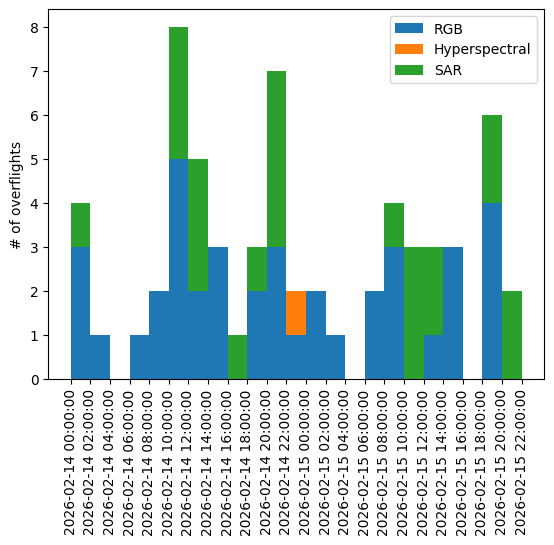

In [15]:
fig, ax = plt.subplots()

bins_dt = [start_time+i*dt.timedelta(seconds=7200) for i in range(24)]
bins = [t.timestamp() for t in bins_dt]

n, bins, patches = ax.hist([
    [o['highest_time'].timestamp() for o in opportunities_list if o['instrument']==instrument]
    for instrument in instrument_types
],
    bins=bins,
    histtype='barstacked',
    label = instrument_types,
    )

ax.set_xticks(bins)
ax.set_xticklabels([dt.datetime.fromtimestamp(b) for b in bins], rotation=90)
ax.set_ylabel("# of overflights")
ax.legend()

plt.savefig("overflights_histogram.pdf")
plt.savefig("overflights_histogram.png")

## On the spatial distribution of overflight opportunities

### Build a tiling around the area of interest

In [16]:
rotterdam_area = h3.LatLngPoly(
    [
        (Rotterdam.lon_deg-4, Rotterdam.lat_deg-4),
        (Rotterdam.lon_deg-4, Rotterdam.lat_deg+4),
        (Rotterdam.lon_deg+4, Rotterdam.lat_deg+4),
        (Rotterdam.lon_deg+4, Rotterdam.lat_deg-4),
     ]
    )
h3_res = 4
all_h3cells = h3.h3shape_to_cells(rotterdam_area, h3_res)
wet_h3cells = []
for _cell in all_h3cells:
    _cell_lon_deg, _cell_lat_deg = h3.cell_to_latlng(_cell)
    if not is_land(_cell_lon_deg, _cell_lat_deg):
        wet_h3cells.append(_cell)

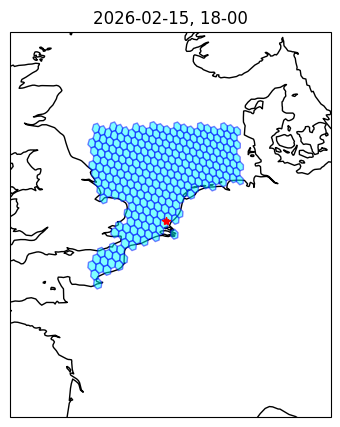

In [17]:

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

_plot_offset_deg = 8

# fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

for (ground_station, satpass) in sat_passes_with_gs:
    axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    
for _cell in wet_h3cells:
    _boundary = h3.cell_to_boundary(_cell)
    _poly = Polygon(_boundary)
    # print(_poly)
    axglobal.add_geometries([_poly], crs=ccrs.PlateCarree(), edgecolor='blue', facecolor='cyan', alpha=0.5)

axglobal.set_title("{}-{}".format(min_time.strftime("%Y-%m-%d, %H"), (min_time+duration).strftime("%H")))
# plt.show()
axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())


### For each tile, create a request

In [18]:
duration_h = 6

overflights = {dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0): {} for start_day in range(14,16) for start_hour in range(0,24,duration_h)}

for start_day in range(14,16):
    for start_hour in range(0,24,duration_h):
        min_time = dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0)
        duration = dt.timedelta(seconds=3600*duration_h)
        
        for _cell in wet_h3cells:
            
            _cell_lon_deg, _cell_lat_deg = h3.cell_to_latlng(_cell)
            _obs_requests = [
                ObservationRequest(_cell_lon_deg, _cell_lat_deg, min_time=min_time, max_time=min_time+duration, alt_km=0, request_name=_cell, min_elevation_deg=45, instrument=instrument)
                for instrument in instrument_types
            ]
            _opportunities = find_observation_opportunities(_obs_requests, all_satellites)
            overflights[min_time][_cell] = _opportunities

overflights_count = {}
for _start_time in overflights.keys():
    overflights_count[_start_time] = {}
    for _cell in overflights[_start_time].keys():
        overflights_count[_start_time][_cell] = {}
        overflights_count[_start_time][_cell]['total'] = 0
        for _request in overflights[_start_time][_cell].keys():
            _num_overflights = len(overflights[_start_time][_cell][_request])
            overflights_count[_start_time][_cell][_request.instrument] = _num_overflights
            overflights_count[_start_time][_cell]['total'] += _num_overflights

#### How many overflights per tile do we get in a 6h window?

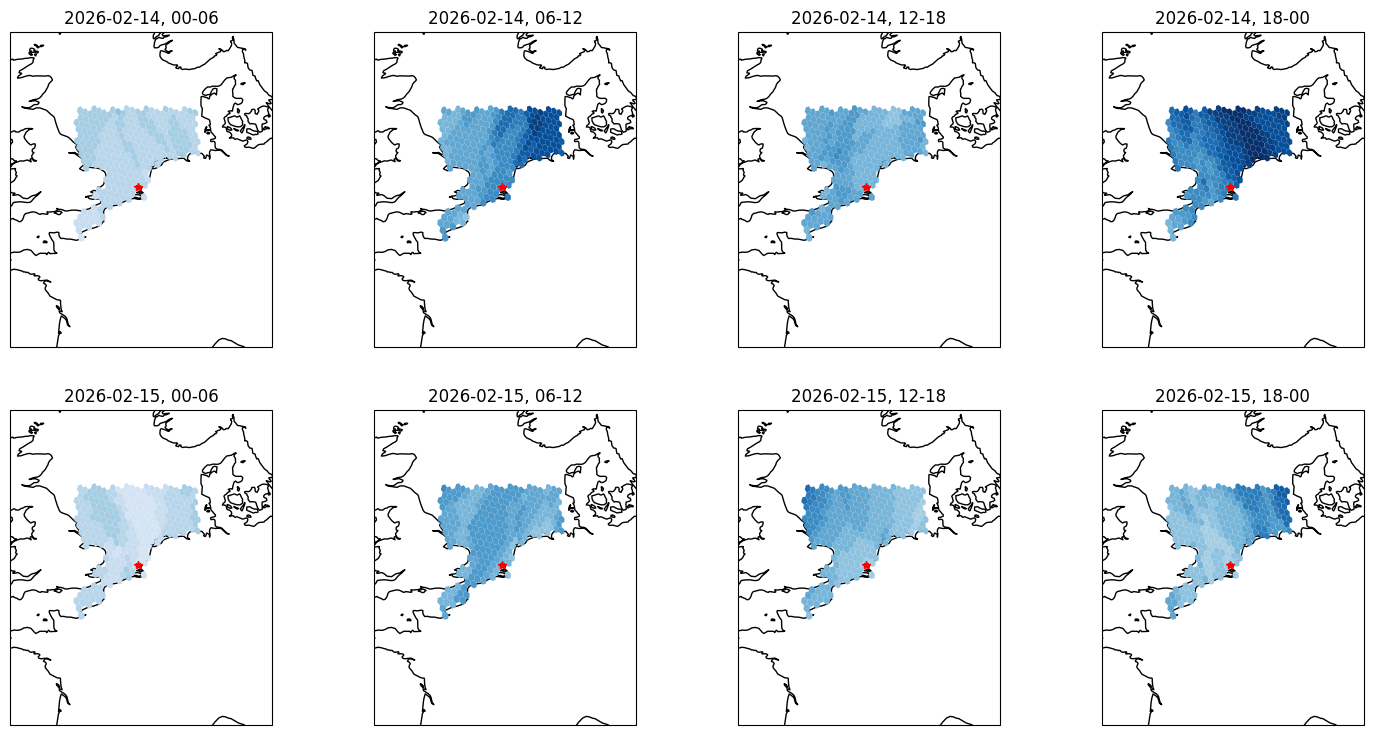

In [19]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

max_num_overflights = max([stats['total'] for _dt in overflights_count.keys() for stats in overflights_count[_dt].values()])

figglobal = plt.figure(figsize=(18,9))

plt_index = 0

# axgloballgd = figglobal.add_subplot(2,4,8)
# # axgloballgd.set_axis_off()
# divider = make_axes_locatable(axgloballgd)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# # fig.colorbar(im1, cax=cax, orientation='vertical')

# figglobal.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, max_num_overflights), cmap='Blues'),
#             ax=cax, orientation='vertical', label='# of overflights')

for start_time in overflights_count.keys():
    cmap = mpl.colormaps["Blues"]
    # figglobal = plt.figure(figsize=(10,5))
    plt_index+=1
    # axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
    axglobal = figglobal.add_subplot(2,4,plt_index, projection=ccrs.Robinson(), )

    # axglobal.set_global()
    axglobal.coastlines()

    _plot_offset_deg = 8

    axglobal.plot(float(Rotterdam.lon_deg), float(Rotterdam.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    for _cell in wet_h3cells:
        _boundary = h3.cell_to_boundary(_cell)
        _poly = Polygon(_boundary)
        # print(_poly)
        num_overflights = overflights_count[start_time][_cell]['total']
        axglobal.add_geometries([_poly], crs=ccrs.PlateCarree(), edgecolor='none', facecolor=cmap(num_overflights/max_num_overflights))

    axglobal.set_title("{}-{}".format(start_time.strftime("%Y-%m-%d, %H"), (start_time+duration).strftime("%H")))
    # plt.show()
    axglobal.set_extent((float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())


plt.savefig("overflights_6h_intervals.pdf", bbox_inches='tight')
plt.savefig("overflights_6h_intervals.png", bbox_inches='tight')

### How about a 1h window?

In [20]:
duration_h = 1

overflights = {dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0): {} for start_day in range(14,16) for start_hour in range(0,24,duration_h)}

for start_day in range(14,16):
    for start_hour in range(0,24,duration_h):
        min_time = dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0)
        duration = dt.timedelta(seconds=3600*duration_h)
        
        for _cell in wet_h3cells:
            
            _cell_lon_deg, _cell_lat_deg = h3.cell_to_latlng(_cell)
            _obs_requests = [
                ObservationRequest(_cell_lon_deg, _cell_lat_deg, min_time=min_time, max_time=min_time+duration, alt_km=0, request_name=_cell, min_elevation_deg=45, instrument=instrument)
                for instrument in instrument_types
            ]
            _opportunities = find_observation_opportunities(_obs_requests, all_satellites)
            overflights[min_time][_cell] = _opportunities

overflights_count = {}
for _start_time in overflights.keys():
    overflights_count[_start_time] = {}
    for _cell in overflights[_start_time].keys():
        overflights_count[_start_time][_cell] = {}
        overflights_count[_start_time][_cell]['total'] = 0
        for _request in overflights[_start_time][_cell].keys():
            _num_overflights = len(overflights[_start_time][_cell][_request])
            overflights_count[_start_time][_cell][_request.instrument] = _num_overflights
            overflights_count[_start_time][_cell]['total'] += _num_overflights

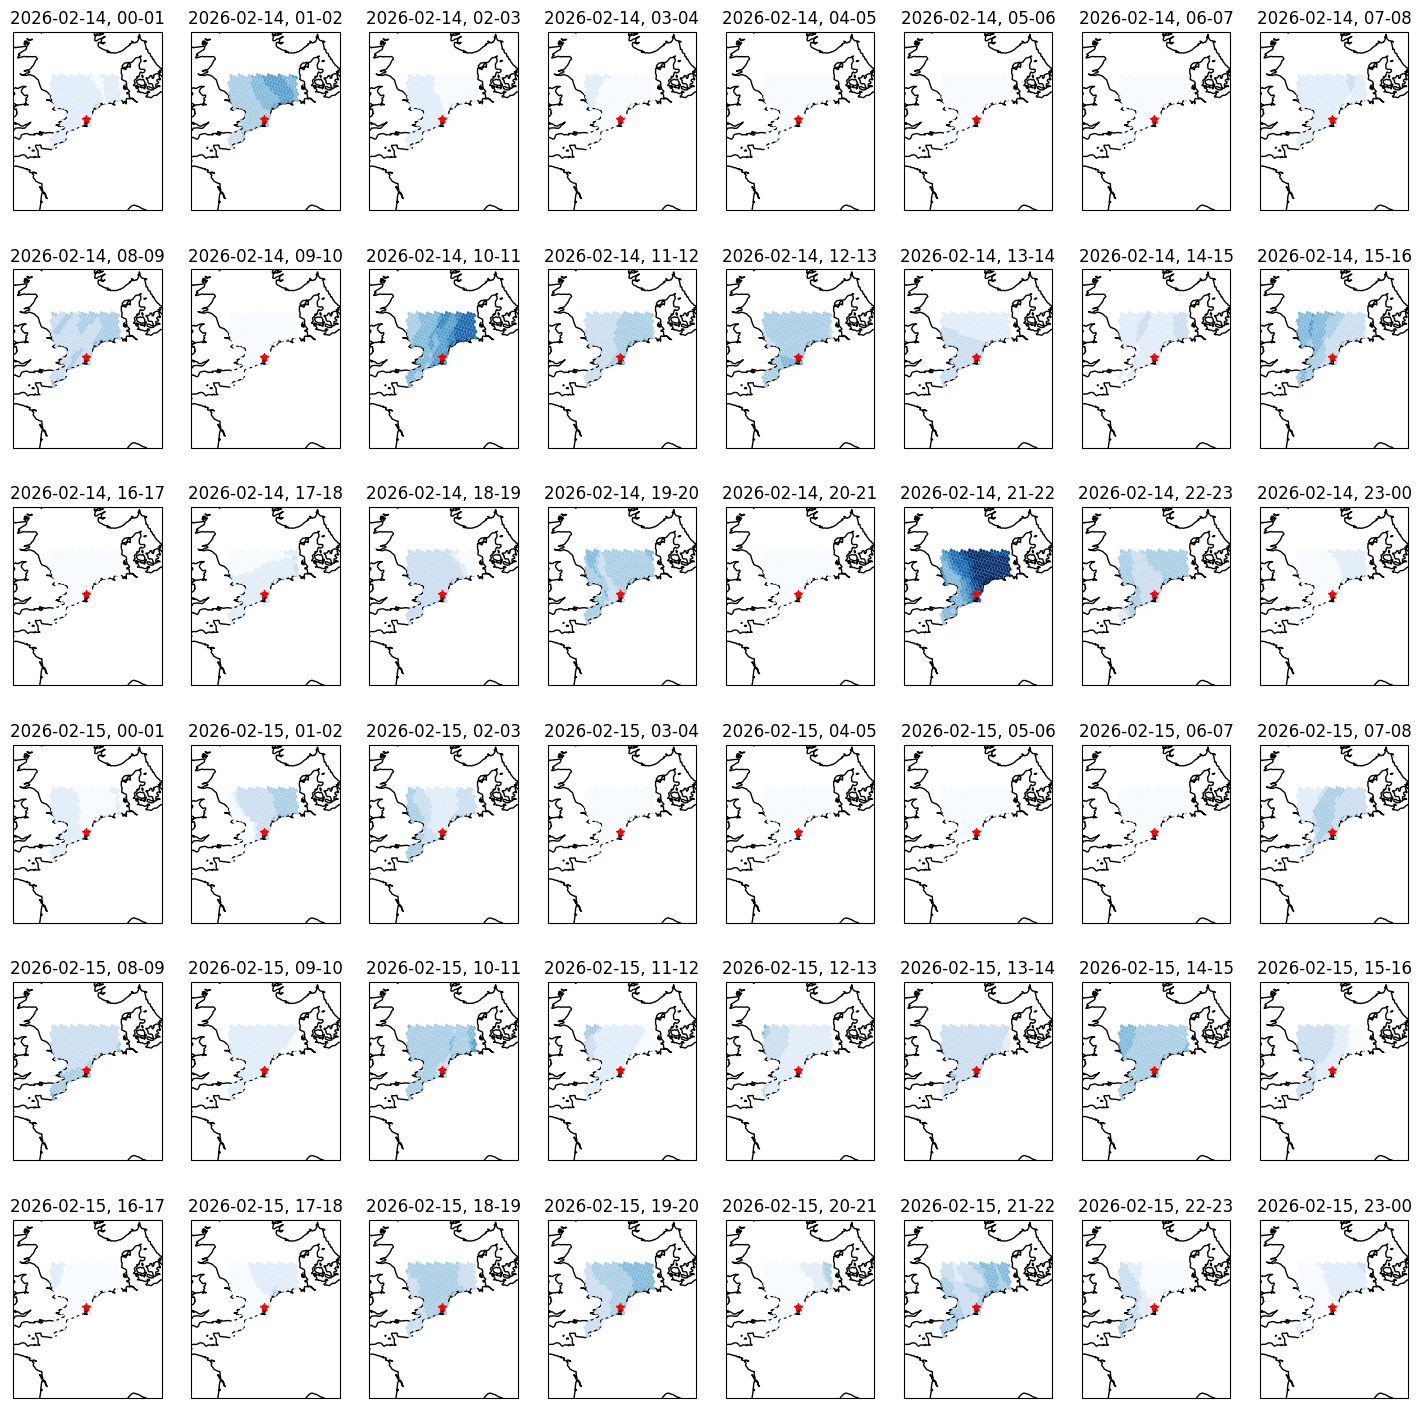

In [21]:
max_num_overflights = max([stats['total'] for _dt in overflights_count.keys() for stats in overflights_count[_dt].values()])

figglobal = plt.figure(figsize=(18,18))
# axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())

plt_index = 0
for start_time in overflights_count.keys():
    cmap = mpl.colormaps["Blues"]
    # figglobal = plt.figure(figsize=(10,5))
    plt_index+=1
    axglobal = figglobal.add_subplot(6,8,plt_index, projection=ccrs.Robinson())
    
    # axglobal.set_global()
    axglobal.coastlines()

    _plot_offset_deg = 8

    axglobal.plot(float(Rotterdam.lon_deg), float(Rotterdam.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    for _cell in wet_h3cells:
        _boundary = h3.cell_to_boundary(_cell)
        _poly = Polygon(_boundary)
        # print(_poly)
        num_overflights = overflights_count[start_time][_cell]['total']
        axglobal.add_geometries([_poly], crs=ccrs.PlateCarree(), edgecolor='none', facecolor=cmap(num_overflights/max_num_overflights))

    axglobal.set_title("{}-{}".format(start_time.strftime("%Y-%m-%d, %H"), (start_time+duration).strftime("%H")))
    # plt.show()
    axglobal.set_extent((float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())

# figglobal.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, max_num_overflights), cmap='Blues'),
#             ax=axglobal, orientation='vertical', label='# of overflights')

plt.savefig("overflights_1h_intervals.pdf", bbox_inches='tight')
plt.savefig("overflights_1h_intervals.png", bbox_inches='tight')

### How many 1h intervals have at least an overflight?